<a href="https://colab.research.google.com/github/purnachand1186/Breast_Cancer_Analysis_ML/blob/main/2_Evaluation_ML_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OVERVIEW**

This is continutation of what we have found in the '1_Exploratary_Data_Analysis_Breast_Cancer' notebook.

So far we have analyzed the data , removed any unncessary columns, removed outliers and normalized the data, in this notebook, we will be using multiple ML models to process the data and find out the best performing model with accuracy and time it took perform the predictions.

### Load Required Python Libraries

In [ ]:
!pip install scikeras

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import time



from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder,LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score,make_scorer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#For neaural networks

from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasRegressor


import warnings
warnings.filterwarnings('ignore')

In [ ]:
import logging
logging.getLogger().setLevel(logging.CRITICAL)

### Read the data prepared in the first notebook

In [ ]:
#read the normalized data from csv file from data folder
cancer_data = pd.read_csv('data/cancer_normalized_df.csv')
cancer_data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711,0
1,0.258839,0.202570,0.267984,0.141506,0.678613,0.461996,0.369728,0.402038,0.518687,0.551179,...,0.312633,0.263908,0.136748,0.712739,0.482784,0.427716,0.598282,0.477035,0.454939,0
2,0.533343,0.347311,0.523875,0.380276,0.379164,0.274891,0.264058,0.367793,0.370707,0.157119,...,0.416844,0.511928,0.349194,0.482269,0.223448,0.302236,0.663918,0.295289,0.187853,0
3,0.318472,0.376057,0.320710,0.184263,0.598267,0.445126,0.219447,0.297465,0.573737,0.517060,...,0.429638,0.299766,0.174941,0.622268,0.330753,0.213898,0.534708,0.321506,0.393939,0
4,0.284869,0.409537,0.302052,0.159618,0.674099,0.533157,0.435567,0.464861,0.651515,0.504002,...,0.498667,0.277852,0.136183,0.654626,0.497531,0.430511,0.707904,0.554504,0.342123,0


In [ ]:
#split the data for training and testing
X = cancer_data.drop('target', axis=1)
y = cancer_data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Evaluation

Execute Base Models without any param grid and find out the accuracy scores on test data

In [ ]:
base_models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Naive Bayes': GaussianNB()
}

In [ ]:
results_base= []
for model_name, model in base_models.items():
    pipe = Pipeline([
        # ('scaler', StandardScaler()),
        ('model', model)
    ])
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    train_time = end_time - start_time
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)
    results_base.append({'Model': model_name, 'Train Time': train_time, 'Train Accuracy': train_score, 'Test Accuracy': test_score})

In [ ]:
results_base_mdls = pd.DataFrame(results_base)
results_base_mdls

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.010652,0.951872,0.968085
1,Decision Tree,0.009870,1.000000,0.936170
2,KNN,0.002106,0.973262,0.978723
3,Random Forest,0.165629,1.000000,0.978723
4,SVM,0.003331,0.975936,0.989362
5,Gradient Boosting,0.326148,1.000000,0.978723
6,Naive Bayes,0.001641,0.935829,0.936170


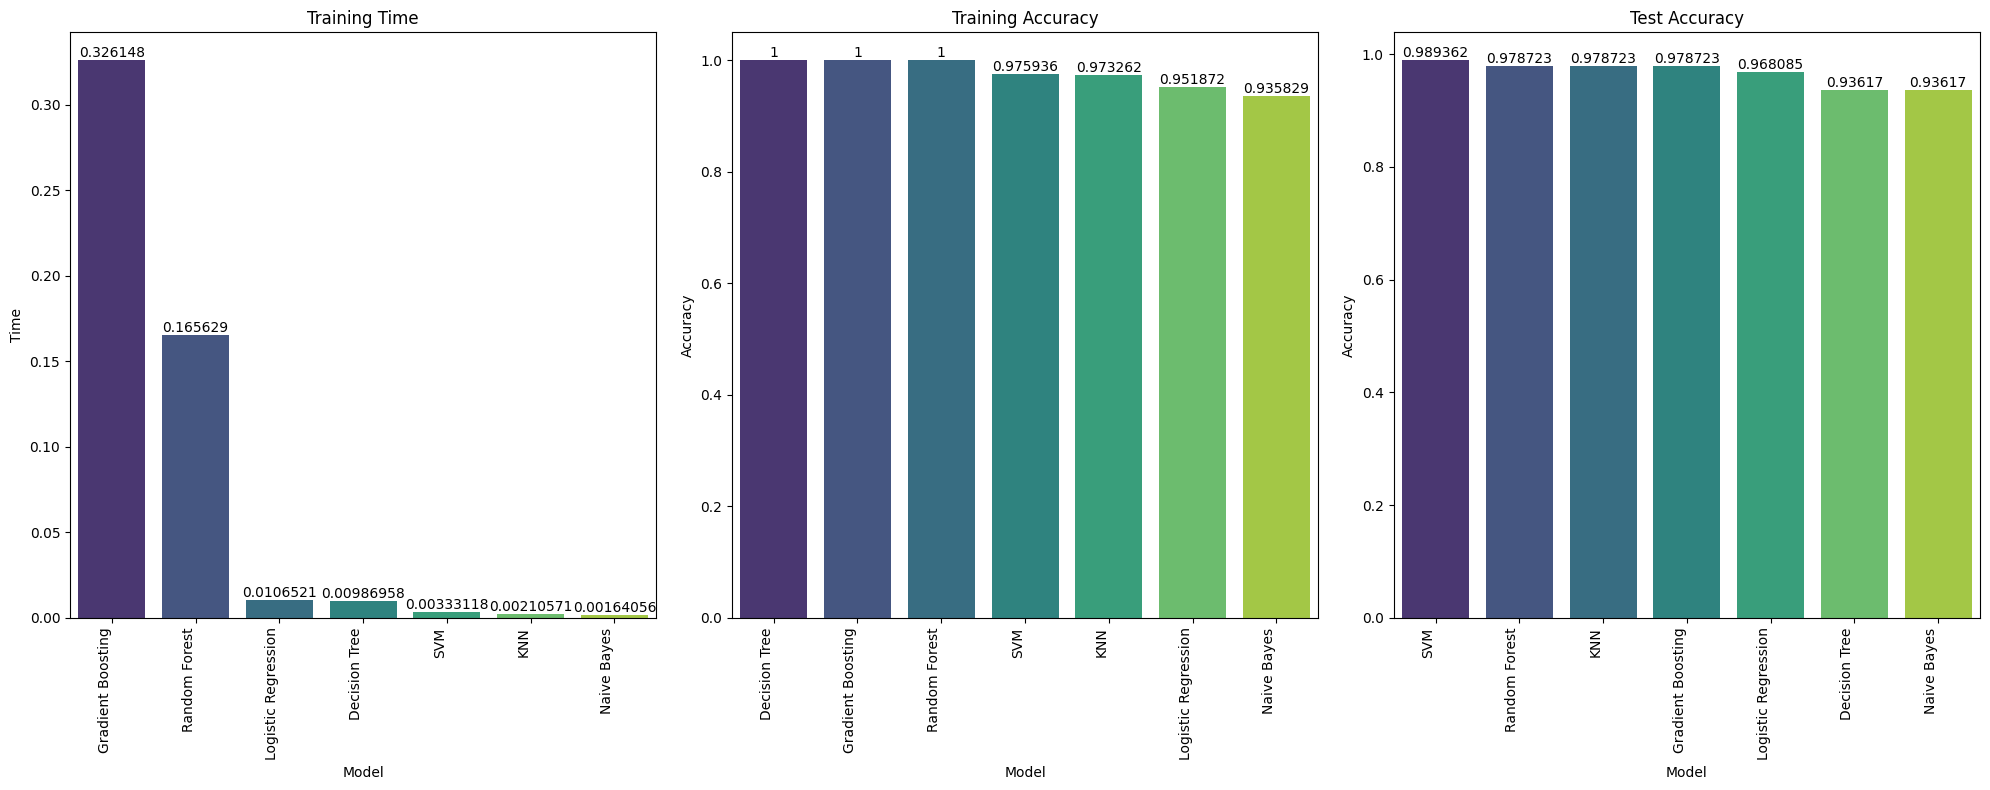

In [ ]:
#draw diagrams using the data from above
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
fig = sns.barplot(x='Model', y='Train Time', data=results_base_mdls.sort_values(by='Train Time', ascending=False), palette='viridis', ax=ax[0])
fig.set_title('Training Time')
fig.set_xlabel('Model')
fig.set_ylabel('Time')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90,ha="right")
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Train Accuracy', data=results_base_mdls.sort_values(by='Train Accuracy', ascending=False), palette='viridis', ax=ax[1])
fig.set_title('Training Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90,ha="right")
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Test Accuracy', data=results_base_mdls.sort_values(by='Test Accuracy', ascending=False), palette='viridis', ax=ax[2])
fig.set_title('Test Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90,ha="right")
for container in fig.containers:
    fig.bar_label(container)

plt.savefig('images/base_model_comparison.jpeg')
plt.tight_layout()
plt.show()

###Observtions

With just basic default parameters SVM model performed better with Test data and Gradient boosting & KNN follows next.

Overall KNN took less time to train and results an accuracy of 0.978 with test data

##Tuning hyperparameters

In [ ]:
# define hyper parameters for the above defined based models
param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1, 10,100]},
    'Decision Tree': {'classifier__max_depth': [3,5,7,9,15]},
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10,20,30]},
    'SVM': {'classifier__C': [0.1, 1, 10,100], 'classifier__kernel': ['linear', 'rbf']},
    'KNN': {'classifier__n_neighbors': [3, 5, 7,9]},
    'Gradient Boosting': {'classifier__n_estimators': [100, 200], 'classifier__learning_rate': [0.01, 0.1]},
    'Naive Bayes': {}
}

In [ ]:
# Define the scoring metrics for scikit-learn > 1.5.1
# scoring = {
#     'precision': make_scorer(precision_score),
#     'recall': make_scorer(recall_score),
#     'f1': make_scorer(f1_score)
# }

In [ ]:
scoring={'precision':'precision',
'recall':'recall',
'f1':'f1'
}

In [ ]:
# execute Grid Search
results_advanced = []
for model_name in base_models:
    pipeline = Pipeline([
        ('classifier', base_models[model_name])
    ])
    grid_search = GridSearchCV(pipeline, param_grid=param_grids[model_name], scoring=scoring, refit='f1', cv=5)
    # Fit the model and time it
    start_time = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid_search.cv_results_['mean_fit_time'])

    best_params = grid_search.best_params_
    best_precision = grid_search.cv_results_['mean_test_precision'][grid_search.best_index_]
    best_recall = grid_search.cv_results_['mean_test_recall'][grid_search.best_index_]
    best_f1 = grid_search.cv_results_['mean_test_f1'][grid_search.best_index_]
    # Get the best estimator
    best_model = grid_search.best_estimator_
    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)

    # Append the results
    results_advanced.append({'Model': model_name, 'Train Time': fit_time, 'Train Accuracy': train_score, 'Test Accuracy': test_score, 'Precision': best_precision, 'Recall': best_recall, 'F1': best_f1, 'Best Params':grid_search.best_params_ })

In [ ]:
# Set display options to show all rows and columns
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
results_adv = pd.DataFrame(results_advanced)
results_adv


,Model,Train Time,Train Accuracy,Test Accuracy,Precision,Recall,F1,Best Params
0,Logistic Regression,0.067865,0.978610,0.989362,0.968523,0.985714,0.976892,{'classifier__C': 10}
1,Decision Tree,0.060468,0.962567,0.946809,0.923036,0.942792,0.932514,{'classifier__max_depth': 3}
2,KNN,0.063013,0.973262,0.978723,0.965273,0.992857,0.978822,{'classifier__n_neighbors': 5}
3,Random Forest,1.416314,1.000000,0.968085,0.961745,0.978571,0.969845,"{'classifier__max_depth': 10, 'classifier__n_e..."
4,SVM,0.096620,0.989305,0.978723,0.968717,0.992857,0.980497,"{'classifier__C': 10, 'classifier__kernel': 'r..."
5,Gradient Boosting,2.634198,1.000000,0.978723,0.951467,0.982143,0.966432,"{'classifier__learning_rate': 0.1, 'classifier..."
6,Naive Bayes,0.036621,0.935829,0.936170,0.970264,0.935649,0.952316,{}


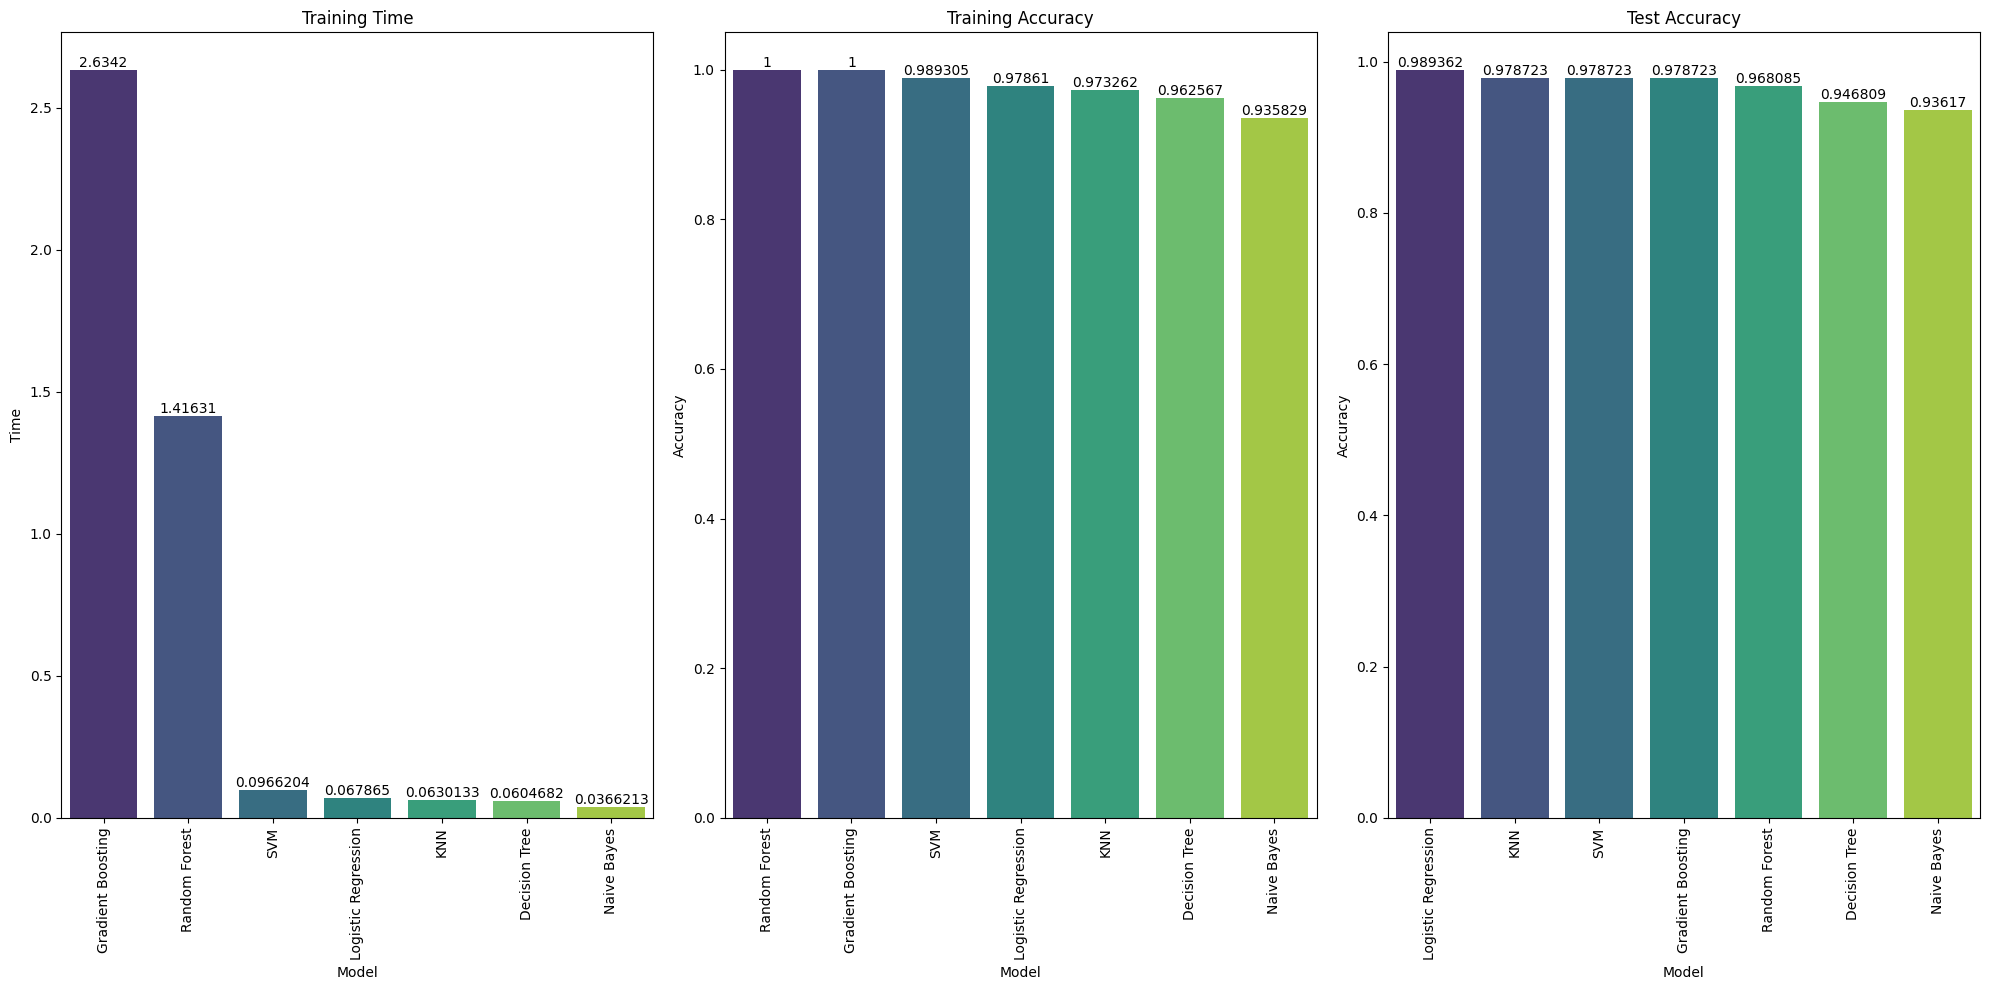

In [ ]:
#draw diagrams using the data from above
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
fig = sns.barplot(x='Model', y='Train Time', data=results_adv.sort_values(by='Train Time', ascending=False), palette='viridis', ax=ax[0])
fig.set_title('Training Time')
fig.set_xlabel('Model')
fig.set_ylabel('Time')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Train Accuracy', data=results_adv.sort_values(by='Train Accuracy', ascending=False), palette='viridis', ax=ax[1])
fig.set_title('Training Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
for container in fig.containers:
    fig.bar_label(container)
fig = sns.barplot(x='Model', y='Test Accuracy', data=results_adv.sort_values(by='Test Accuracy', ascending=False), palette='viridis', ax=ax[2])
fig.set_title('Test Accuracy')
fig.set_xlabel('Model')
fig.set_ylabel('Accuracy')
fig.set_xticklabels(fig.get_xticklabels(), rotation=90)
for container in fig.containers:
    fig.bar_label(container)

# for i in range(len(results_adv)):
#     ax[0].text(i - 0.2, results_adv.loc[i, 'Train Time'], f'{results_adv.loc[i, "Train Time"]:.2f}', color='black', ha="center")
#     ax[1].text(i - 0.2, results_adv.loc[i, 'Train Accuracy'], f'{results_adv.loc[i, "Train Accuracy"]:.2f}', color='black', ha="center")
#     ax[2].text(i - 0.2, results_adv.loc[i, 'Test Accuracy'], f'{results_adv.loc[i, "Test Accuracy"]:.2f}', color='black', ha="center")
fig
plt.savefig('images/advanced_model_comparison.jpeg')
plt.tight_layout()
plt.show()

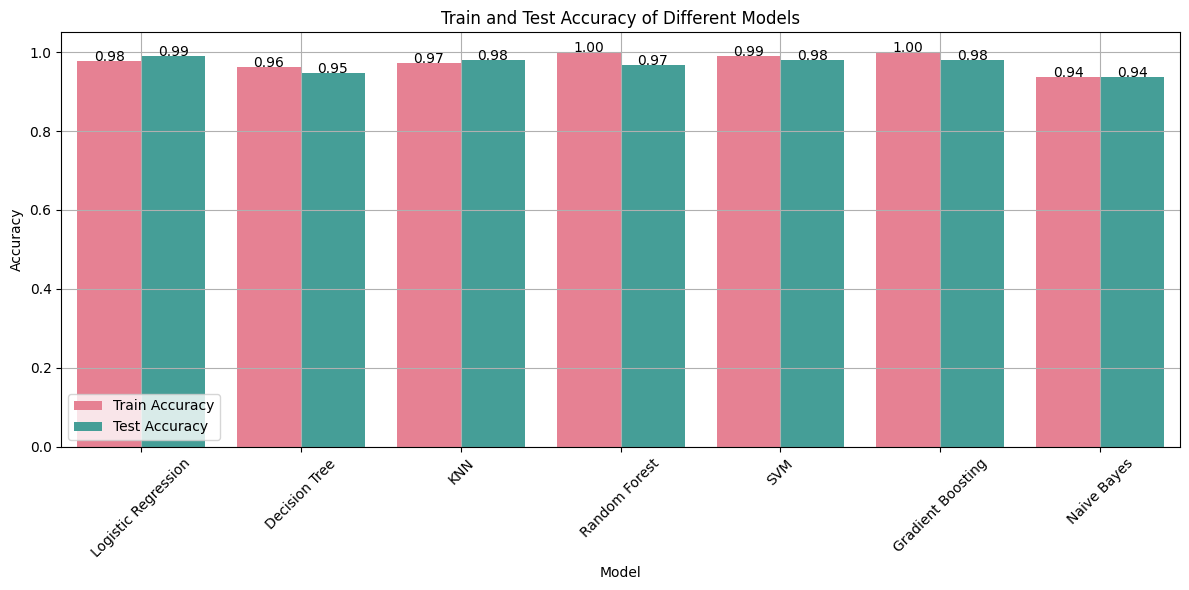

In [ ]:
# Melt the DataFrame for easier plotting with sns.barplot
accuracy_df_melted = results_adv.melt(id_vars='Model', value_vars=['Train Accuracy', 'Test Accuracy'], var_name='Dataset', value_name='Accuracy')
# Plot the accuracies using sns.barplot and show values up to two decimals
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Accuracy', hue='Dataset', data=accuracy_df_melted, palette='husl')


for i in range(len(results_adv)):
    plt.text(i - 0.2, results_adv.loc[i, 'Train Accuracy'], f'{results_adv.loc[i, "Train Accuracy"]:.2f}', color='black', ha="center")
    plt.text(i + 0.2, results_adv.loc[i, 'Test Accuracy'], f'{results_adv.loc[i, "Test Accuracy"]:.2f}', color='black', ha="center")

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy of Different Models')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('images/train_test_accuracies_advanced.jpeg')
plt.show()

###Observations

With advanced parameters , surprinsingly Logistic regression performed better with  test data and KNN , Random Forest followed later.

## Use Neaural networks to find out if we find any better scores

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss = 'bce', metrics = ['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
           epochs = 10, verbose = 0)
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Generate classification report
y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9553 - loss: 0.2673
Test Accuracy: 95.74%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.97      0.97      0.97        77

    accuracy                           0.96        94
   macro avg       0.93      0.93      0.93        94
weighted avg       0.96      0.96      0.96        94



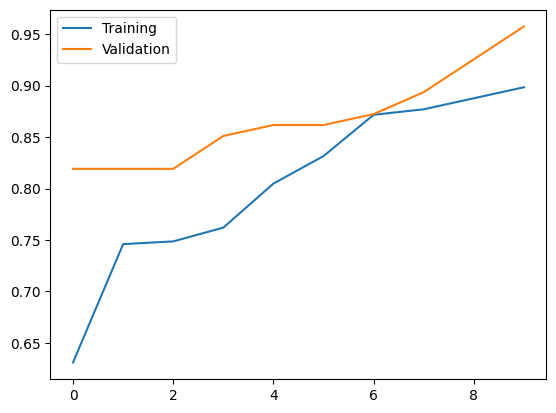

In [ ]:
### ANSWER
#print(history.history['acc'][-1])
accuracies = history.history['accuracy']
validation_accuracies = history.history['val_accuracy']


## Plot Training and Validations
plt.plot(accuracies, label = 'Training')
plt.plot(validation_accuracies, label = 'Validation')
plt.legend();

#Using Grid Search in Neaural network to identify best model


In [ ]:
def create_model(**kwargs):
  model = Sequential()
  model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
  model.add(Dense(32, activation='relu'))
  model.add(Dense(1, activation='sigmoid'))
  model.compile(loss = 'bce', metrics = ['accuracy'])
  return model

In [ ]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.2.2

In [ ]:
# Keras model with SciKeras wrapper
model = KerasRegressor(model = create_model,verbose=2)
tf.random.set_seed(42)
# Hyperparameters to be optimized
param_grid = {
  'model__neurons' : [10, 50, 100],
  'model__activation': ['relu', 'sigmoid'],
  'model__optimizer': ['adam', 'sgd'],
  'batch_size': [1, 10],
  'epochs': [10, 20]
}
# GridSearchCV for hyperparameter tuning
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3)

# Fit the model
grid_result = grid.fit(X, y)

In [ ]:
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: -0.037736 using {'batch_size': 1, 'epochs': 20, 'model__activation': 'sigmoid', 'model__neurons': 50, 'model__optimizer': 'sgd'}


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [1]:
!pip install kaggle

In [2]:
#download CBIS DDSM breast Cencer Image dataset
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
cbis-ddsm-breast-cancer-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


##Import required Python Modules

In [39]:
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from transformers import pipeline
import PIL
import plotly.express as px

### Unzip downloaded data into a folder

In [4]:
# Extract the dataset
with zipfile.ZipFile('cbis-ddsm-breast-cancer-image-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('cbis_ddsm_image_data')

In [12]:
metadata = pd.read_csv('cbis_ddsm_image_data/csv/calc_case_description_train_set.csv')
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1546 non-null   object
 1   breast density           1546 non-null   int64 
 2   left or right breast     1546 non-null   object
 3   image view               1546 non-null   object
 4   abnormality id           1546 non-null   int64 
 5   abnormality type         1546 non-null   object
 6   calc type                1526 non-null   object
 7   calc distribution        1170 non-null   object
 8   assessment               1546 non-null   int64 
 9   pathology                1546 non-null   object
 10  subtlety                 1546 non-null   int64 
 11  image file path          1546 non-null   object
 12  cropped image file path  1546 non-null   object
 13  ROI mask file path       1546 non-null   object
dtypes: int64(4), object(10)
memory usage: 16

In [86]:
dicom_data = pd.read_csv('cbis_ddsm_image_data/csv/dicom_info.csv')
dicom_data.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [87]:
dicom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10237 entries, 0 to 10236
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   file_path                                    10237 non-null  object 
 1   image_path                                   10237 non-null  object 
 2   AccessionNumber                              0 non-null      float64
 3   BitsAllocated                                10237 non-null  int64  
 4   BitsStored                                   10237 non-null  int64  
 5   BodyPartExamined                             10237 non-null  object 
 6   Columns                                      10237 non-null  int64  
 7   ContentDate                                  10237 non-null  int64  
 8   ContentTime                                  10237 non-null  float64
 9   ConversionType                               10237 non-null  object 
 10

In [88]:
#find null values
dicom_data.isna().sum()

,0
file_path,0
image_path,0
AccessionNumber,10237
BitsAllocated,0
BitsStored,0
BodyPartExamined,0
Columns,0
ContentDate,0
ContentTime,0
ConversionType,0


**patient sex, name, borth date is of no use in the model processing, delete those fields**

In [89]:
#delete columns
dicom_data.drop(['PatientSex', 'ReferringPhysicianName', 'StudyDate', 'PatientBirthDate','StudyTime','AccessionNumber'], axis=1, inplace=True)

In [90]:
#fill na values
dicom_data['SeriesDescription'].fillna(method = 'bfill', axis = 0, inplace=True)
dicom_data['Laterality'].fillna(method = 'bfill', axis = 0, inplace=True)
dicom_data.isna().sum()

<ipython-input-90-cd5624a1851a>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dicom_data['SeriesDescription'].fillna(method = 'bfill', axis = 0, inplace=True)
<ipython-input-90-cd5624a1851a>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dicom_data['SeriesDescription'].fillna(method = 'bfill', axis = 0, inplace=True)
<ipython-input-90-cd5624a1851a>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series throug

,0
file_path,0
image_path,0
BitsAllocated,0
BitsStored,0
BodyPartExamined,0
Columns,0
ContentDate,0
ContentTime,0
ConversionType,0
HighBit,0


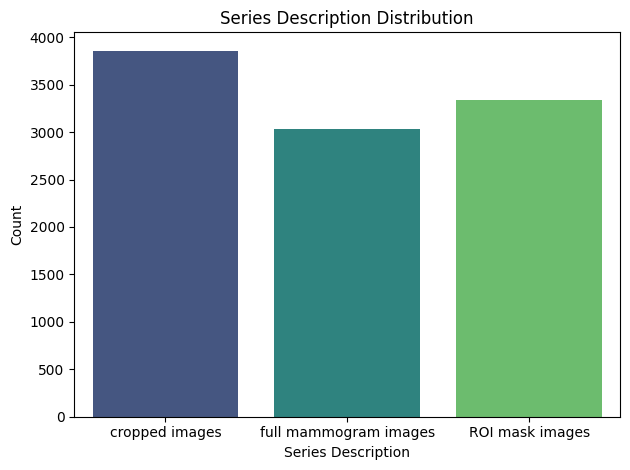

In [91]:
# sort SeriesDescription column draw plot of series description column
sns.countplot(x='SeriesDescription', data=dicom_data, palette='viridis', hue='SeriesDescription')
# plt.xticks(rotation=45)
plt.title('Series Description Distribution')
plt.xlabel('Series Description')
plt.ylabel('Count')
plt.savefig('images/series_description_distribution.jpeg')
plt.tight_layout()
plt.show()

In [125]:
#get cropped images from the dicom_data
dicom_data['image_path'] = dicom_data['image_path'].apply(lambda x: x.replace('CBIS-DDSM/jpeg', 'cbis_ddsm_image_data/jpeg'))
cropped_images,full_mammo,roi_images = dicom_data[dicom_data['SeriesDescription']=='cropped images'].image_path, dicom_data[dicom_data['SeriesDescription']=='full mammogram images'].image_path, dicom_data[dicom_data['SeriesDescription']=='ROI mask images'].image_path
crop_dict = {}
full_dict = {}
roi_dict = {}
for path in cropped_images:
  crop_dict[path.split('/')[2]] = path
for path in full_mammo:
  full_dict[path.split('/')[2]] = path
for path in roi_images:
  roi_dict[path.split('/')[2]] = path

In [126]:
crop_dict

{'1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg',
 '1.3.6.1.4.1.9590.100.1.2.381187369611524586537789902641525311317': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.381187369611524586537789902641525311317/1-052.jpg',
 '1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/1-034.jpg',
 '1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091/1-149.jpg',
 '1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/1-003.jpg',
 '1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.23637354871299

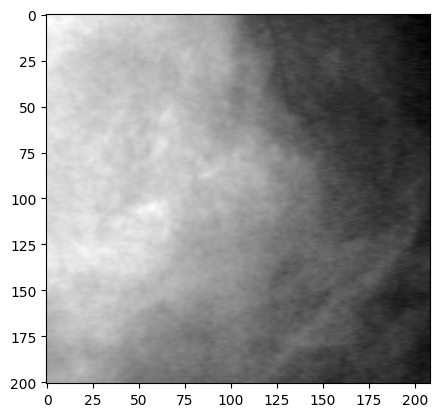

In [33]:
for file  in cropped_images[0:100]:
  cropped_images_show = PIL.Image.open(file)
  gray_img= cropped_images_show.convert("L")
  plt.imshow(gray_img, cmap='gray')

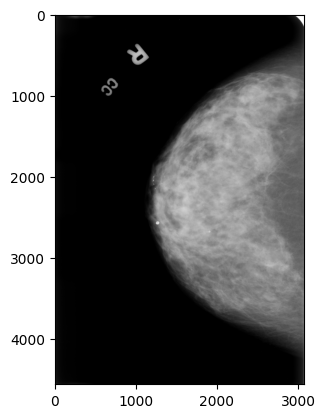

In [38]:
for file  in full_mammo[0:5]:
  full_mammo_images_show = PIL.Image.open(file)
  gray_img= full_mammo_images_show.convert("L")
  plt.imshow(gray_img, cmap='gray')

In [71]:
# read csv file data for train & test data
calc_train_data = pd.read_csv('cbis_ddsm_image_data/csv/calc_case_description_train_set.csv')
calc_test_data = pd.read_csv('cbis_ddsm_image_data/csv/calc_case_description_test_set.csv')
mass_train_data = pd.read_csv('cbis_ddsm_image_data/csv/mass_case_description_train_set.csv')
mass_test_data = pd.read_csv('cbis_ddsm_image_data/csv/mass_case_description_test_set.csv')

In [72]:
calc_train_data.columns

Index(['patient_id', 'breast density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'calc type', 'calc distribution',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='object')

In [73]:
calc_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1546 non-null   object
 1   breast density           1546 non-null   int64 
 2   left or right breast     1546 non-null   object
 3   image view               1546 non-null   object
 4   abnormality id           1546 non-null   int64 
 5   abnormality type         1546 non-null   object
 6   calc type                1526 non-null   object
 7   calc distribution        1170 non-null   object
 8   assessment               1546 non-null   int64 
 9   pathology                1546 non-null   object
 10  subtlety                 1546 non-null   int64 
 11  image file path          1546 non-null   object
 12  cropped image file path  1546 non-null   object
 13  ROI mask file path       1546 non-null   object
dtypes: int64(4), object(10)
memory usage: 16

In [74]:
#convert all object type columns to category
calc_train_data['pathology'] = calc_train_data['pathology'].astype('category')
calc_train_data['calc type'] = calc_train_data['calc type'].astype('category')
calc_train_data['calc distribution'] = calc_train_data['calc distribution'].astype('category')
calc_train_data['abnormality type'] = calc_train_data['abnormality type'].astype('category')
calc_train_data['image view'] = calc_train_data['image view'].astype('category')
calc_train_data['left or right_breast'] = calc_train_data['left or right breast'].astype('category')

In [75]:
calc_train_data.isna().sum()

,0
patient_id,0
breast density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
calc type,20
calc distribution,376
assessment,0
pathology,0


In [ ]:
calc_train_data['calc type'].fillna(method = 'bfill', axis = 0, inplace=True)
calc_train_data['calc distribution'].fillna(method = 'bfill', axis = 0, inplace=True)

In [80]:
#convert all object type columns to category
mass_train_data['pathology'] = mass_train_data['pathology'].astype('category')
mass_train_data['mass shape'] = mass_train_data['mass shape'].astype('category')
mass_train_data['mass margins'] = mass_train_data['mass margins'].astype('category')
mass_train_data['abnormality type'] = mass_train_data['abnormality type'].astype('category')
mass_train_data['image view'] = mass_train_data['image view'].astype('category')
mass_train_data['left or right_breast'] = mass_train_data['left or right_breast'].astype('category')

In [79]:
mass_train_data.isna().sum()

,0
patient_id,0
breast_density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
mass shape,4
mass margins,43
assessment,0
pathology,0


In [109]:
next(iter((full_dict.items())))

('1-249.jpg',
 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.73981681510834344532471573822608492548/1-249.jpg')

In [ ]:
roi_dict

In [83]:
mass_train_data['mass margins'].bfill(inplace=True)
mass_train_data['mass shape'].bfill(inplace=True)
mass_train_data.isna().sum()

<ipython-input-83-f92a30f8861e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  mass_train_data['mass shape'].bfill(inplace=True)


,0
patient_id,0
breast_density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
mass shape,0
mass margins,0
assessment,0
pathology,0


In [128]:
roi_dict


{'1.3.6.1.4.1.9590.100.1.2.381187369611524586537789902641525311317': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.381187369611524586537789902641525311317/2-204.jpg',
 '1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg',
 '1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.178994714611485132105265512043047466091/2-127.jpg',
 '1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/2-281.jpg',
 '1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg',
 '1.3.6.1.4.1.9590.100.1.2.357008050412534761329866492500201501919': 'cbis_ddsm_image_data/jpeg/1.3.6.1.4.1.9590.100.1.2.35700805041253

In [129]:
#fix images in the mass train df
for i,row in enumerate(mass_train_data.values):
  img_name = row[11].split('/')[2]
  print(img_name)
  if img_name in roi_dict.keys():
    mass_train_data.loc[i, 'ROI mask file path'] = roi_dict[img_name]
    print("added to ROI")
  if img_name in crop_dict.keys():
    mass_train_data.loc[i, 'cropped image file path'] = crop_dict[img_name]
    print("added to Cropped")
  if img_name in full_dict.keys():
    mass_train_data.loc[i, 'image file path'] = full_dict[img_name]
    print("added to Image")

1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515
added to Image
1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834
added to Image
1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540
added to Image
1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162
added to Image
1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890
added to Image
1.3.6.1.4.1.9590.100.1.2.392091931911637760938815694332198115839
added to Image
1.3.6.1.4.1.9590.100.1.2.18553022011298363903753970133853455201
added to Image
1.3.6.1.4.1.9590.100.1.2.399831242111800621220027542190666363688
added to Image
1.3.6.1.4.1.9590.100.1.2.353764633213863442442494539840710764601
added to Image
1.3.6.1.4.1.9590.100.1.2.301773695910378556700140939623830965391
added to Image
1.3.6.1.4.1.9590.100.1.2.145557498613842583714429986600518227573
added to Image
1.3.6.1.4.1.9590.100.1.2.369287458813355648611939058220166307923
added to Image
1.3.6.1.4.1.9590.100.1.2.23851732881217929

In [121]:
mass_train_data['ROI mask file path']

,ROI mask file path
0,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....
...,...
1313,Mass-Training_P_02033_RIGHT_MLO_1/1.3.6.1.4.1....
1314,Mass-Training_P_02079_RIGHT_CC_1/1.3.6.1.4.1.9...
1315,Mass-Training_P_02079_RIGHT_MLO_1/1.3.6.1.4.1....
1316,Mass-Training_P_02092_LEFT_CC_1/1.3.6.1.4.1.95...


In [51]:
#contacte the train and test datasets
train_info = pd.concat([calc_train_data, mass_train_data])
test_info = pd.concat([calc_test_data, mass_test_data])
train_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2864 entries, 0 to 1317
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               2864 non-null   object 
 1   breast density           1546 non-null   float64
 2   left or right breast     2864 non-null   object 
 3   image view               2864 non-null   object 
 4   abnormality id           2864 non-null   int64  
 5   abnormality type         2864 non-null   object 
 6   calc type                1526 non-null   object 
 7   calc distribution        1170 non-null   object 
 8   assessment               2864 non-null   int64  
 9   pathology                2864 non-null   object 
 10  subtlety                 2864 non-null   int64  
 11  image file path          2864 non-null   object 
 12  cropped image file path  2864 non-null   object 
 13  ROI mask file path       2864 non-null   object 
 14  breast_density           1318

In [ ]:
Data_cleaning_1['calc_type'].fillna(method = 'bfill', axis = 0, inplace=True)
Data_cleaning_1['calc_distribution'].fillna(method = 'bfill', axis = 0, inplace=True)

In [52]:
train_info.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast_density,mass shape,mass margins
0,P_00005,3.0,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,NaN,NaN,NaN
1,P_00005,3.0,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,NaN,NaN,NaN
2,P_00007,4.0,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN
3,P_00007,4.0,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN
4,P_00008,1.0,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN


In [ ]:
for i in range(len(cropped_images)):
  img_path = cropped_images[i]
  img = load_img(img_path, target_size=(128, 128))
  img_array = img_to_array(img)
  print()

In [41]:
#create empty lists to store images and labels
train_images = []
train_labels = []
test_images = []
test_labels = []
for i,row in train_info.iterrows():
  file_path = row['image file path'].replace('CBIS-DDSM/jpeg', 'cbis_ddsm_image_data/jpeg')
  #load image
  img = load_img(file_path, target_size=(128, 128))
  #convert image to array
  img_array = img_to_array(img)
  #append to list
  images.append(img_array)
  labels.append(row['pathology'])

KeyError: 'pathology'

In [5]:
#create image generator with rescale 1./255
datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_directory('cbis_ddsm_image_data/', target_size=(224, 224), batch_size=32, class_mode='binary')

Found 10237 images belonging to 2 classes.


In [6]:
#build model using keras
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [7]:
# due to more time its taking for epochs =10, limited epochs to 5
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_gen,epochs=5)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 467s 1s/step - accuracy: 0.9845 - loss: 0.0165
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 1.0000 - loss: 2.8026e-45
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 418s 1s/step - accuracy: 1.0000 - loss: 2.8026e-45
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 421s 1s/step - accuracy: 1.0000 - loss: 2.8026e-45
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 1.0000 - loss: 2.8026e-45


In [59]:
# Load a pre-trained NLP model
model = pipeline('text-classification', model='bert-base-uncased')

# Example text data
text_data = calc_train_data['pathology'].iloc[0]
text_data

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


'MALIGNANT'

In [60]:
# Analyze text data
result = model(text_data)
print(result)

[{'label': 'LABEL_0', 'score': 0.5720041394233704}]


In [61]:
# Example combined data
combined_data = {
    'Image_ID': ['img1', 'img2'],
    'Diagnosis': ['Benign', 'Malignant'],
    'Report_Analysis': ['Positive', 'Negative']
}

df = pd.DataFrame(combined_data)
df.to_csv('data/image_analysis_results.csv', index=False)

# Display the combined results
print(df)

  Image_ID  Diagnosis Report_Analysis
0     img1     Benign        Positive
1     img2  Malignant        Negative
